<a href="https://colab.research.google.com/github/dasm3/Advanced_Data_Resource-SQL-Warehouse-/blob/main/Healthcare_Analytics_UCI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install ucimlrepo imblearn shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [ ]:
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=296)

X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X,y], axis=1)

print("Shape:", df.shape)
df.head()

Shape: (101766, 48)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
print(df.shape)

(101766, 48)


In [ ]:
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique Values:")
print(df.nunique())


Columns:
['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data Types:
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_dispo

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [ ]:
display(df[['race','gender']].head())

,race,gender
0,Caucasian,Female
1,Caucasian,Female
2,AfricanAmerican,Female
3,Caucasian,Male
4,Caucasian,Male


In [ ]:
print("\n First 5 rows")
print(df.head())


 First 5 rows
              race  gender      age weight  admission_type_id  \
0        Caucasian  Female   [0-10)    NaN                  6   
1        Caucasian  Female  [10-20)    NaN                  1   
2  AfricanAmerican  Female  [20-30)    NaN                  1   
3        Caucasian    Male  [30-40)    NaN                  1   
4        Caucasian    Male  [40-50)    NaN                  1   

   discharge_disposition_id  admission_source_id  time_in_hospital payer_code  \
0                        25                    1                 1        NaN   
1                         1                    7                 3        NaN   
2                         1                    7                 2        NaN   
3                         1                    7                 2        NaN   
4                         1                    7                 1        NaN   

          medical_specialty  num_lab_procedures  num_procedures  \
0  Pediatrics-Endocrinology             

Our business problem is:

Was the patient readmitted within 30 days?

In [ ]:
df["readmitted"].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [ ]:
df["readmitted_30"]= (
    df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)
)
df["readmitted_30"].value_counts(normalize=True)

,proportion
readmitted_30,
0,0.888401
1,0.111599


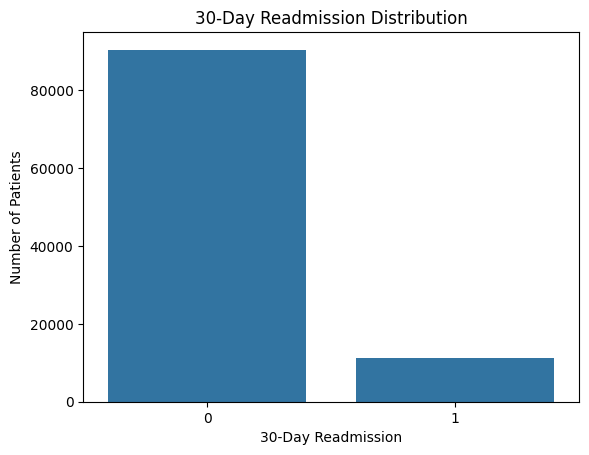

In [ ]:
sns.countplot(data= df, x="readmitted_30")

plt.title("30-Day Readmission Distribution")
plt.xlabel("30-Day Readmission")
plt.ylabel("Number of Patients")
plt.show()


In [ ]:
df["readmitted_after_30"] = (
    df["readmitted"].apply(lambda m: 2 if m == ">30" else 0)
)
df["readmitted_after_30"].value_counts(normalize=True)


,proportion
readmitted_after_30,
0,0.650718
2,0.349282


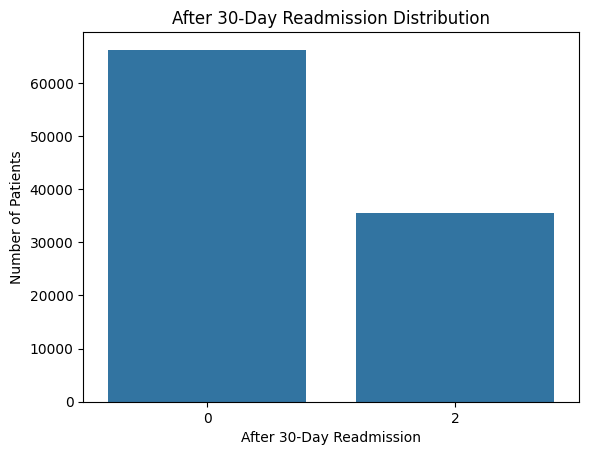

In [ ]:
sns.countplot(data= df, x="readmitted_after_30")

plt.title("After 30-Day Readmission Distribution")
plt.xlabel("After 30-Day Readmission")
plt.ylabel("Number of Patients")
plt.show()

In [ ]:
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30,readmitted_after_30
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0,0
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0,2
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0,0
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0,0
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0,0


In [ ]:
df["No_readmission"] = (
    df["readmitted"].apply(lambda n: 3 if n == "NO" else 0)
)
df["No_readmission"].value_counts(normalize=True)


,proportion
No_readmission,
3,0.539119
0,0.460881


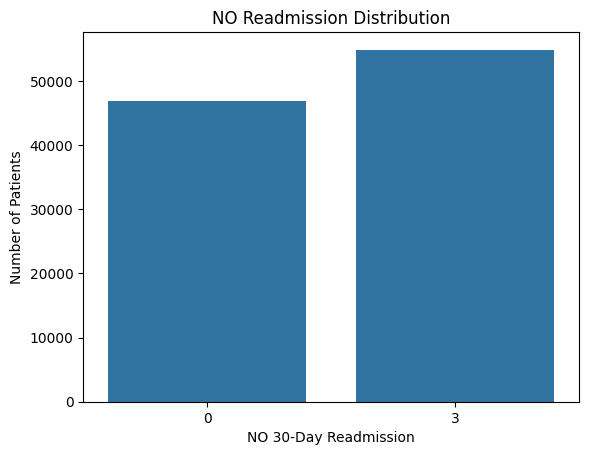

In [ ]:
sns.countplot(data= df, x="No_readmission")

plt.title("NO Readmission Distribution")
plt.xlabel("NO 30-Day Readmission")
plt.ylabel("Number of Patients")
plt.show()

The original target had three categories: readmitted within 30 days, readmitted after 30 days, and no readmission. I converted it into a binary classification problem where <30 represented the positive class and the other two categories represented the negative class.

In [ ]:
df = df.replace("?", np.nan)

In [ ]:
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30,readmitted_after_30,No_readmission
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0,0,3
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0,2,0
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0,0,3
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0,0,3
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0,0,3


In [ ]:
missing = (
    df.isnull().mean().sort_values(ascending = False).mul(100)
)

missing.head(30)

,0
weight,96.858479
max_glu_serum,94.746772
A1Cresult,83.277322
medical_specialty,49.082208
payer_code,39.557416
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636
age,0.000000


Remove extremely Sparse Variables

Because these fields contain substantial missingness and can make the modeling process unnecessarily noisy. The UCI dataset documentation confirms that many demographic, admission, medication and utilization variables are available, while published analyses commonly address missingness during preprocessing.

In [ ]:
columns_to_drop = [
    "weight",
    "payer_code",
    "medical_specialty"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

**Remove Identifiers**

These are identifiers.

They should not be predictive features.

"Why did you remove patient_nbr?"

Answer:

"It is an identifier rather than a clinical predictor. Including it could introduce spurious patterns and potentially create leakage across encounters from the same patient."

In [ ]:
df = df.drop (
    columns = ["encounter_id","patient_number"],
    errors= "ignore"
)

In [ ]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30,readmitted_after_30,No_readmission
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0,0,3
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0,2,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0,0,3
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0,0,3
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0,0,3


Prevent patient-level leakage

The dataset can contain multiple encounters for the same patient.

If the same patient appears in both:

Training

and

Testing

the model may effectively see the same person's history in both datasets.

That's leakage.



For a cleaner portfolio experiment, we'll retain one encounter per patient.

In [ ]:
dataset = fetch_ucirepo(id=296)

raw_X = dataset.data.features
raw_y = dataset.data.targets
raw_ids = dataset.data.ids # Retrieve identifier columns

raw_df = pd.concat([raw_ids, raw_X, raw_y], axis=1) # Concatenate identifiers too

raw_df = raw_df.replace("?", np.nan)
raw_df = raw_df.drop_duplicates(subset = "patient_nbr")

print(raw_df)
print(raw_df.shape)

Buffered data was truncated after reaching the output size limit.

In [ ]:
raw_df["readmitted_30"] = (
    raw_df["readmitted"]
    .apply(lambda x: 1 if x == "<30" else 0)
)

In [ ]:
df.head()

,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30
0,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0
1,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
2,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0
3,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
4,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0


In [ ]:
df = raw_df.copy()

df = df.drop(
    columns=[
        "encounter_id",
        "patient_number",
        "readmitted"
    ],
    errors="ignore"
)

Step 9 — Convert age

Age is stored as intervals such as:

[50-60)
[60-70)
[70-80)

convert them into approximate numeric midpoints.

In [ ]:
age_mapping = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df["age_numeric"] = df["age"].map(age_mapping)

df[["age", "age_numeric"]].head()

,age,age_numeric
0,[0-10),5
1,[10-20),15
2,[20-30),25
3,[30-40),35
4,[40-50),45


In [ ]:
df = df.drop(columns=['age']) #why drop age (it can be used in disease forecasting)

In [ ]:
df.head()

,patient_nbr,race,gender,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30,age_numeric
0,8222157,Caucasian,Female,NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,5
1,55629189,Caucasian,Female,NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,15
2,86047875,AfricanAmerican,Female,NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0,25
3,82442376,Caucasian,Male,NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,35
4,42519267,Caucasian,Male,NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0,45


Step 10 — Diagnosis feature engineering

The raw diagnosis fields look something like:

diag_1
diag_2
diag_3

Rather than throwing raw ICD codes directly into a simple model, we can create broader clinical categories.

In [ ]:
def categorize_diagnosis(code):
  if pd.isna(code):
    return "Unknown"

  code = str(code)

  try:
    num = float(code)
  except:
    return "Other"

  if 390 <= num <= 459 or num == 785:
    return "Circulatory"

  elif 460 <= num <= 519 or num == 786:
    return "Respiratory"

  elif 520 <= num <= 579 or num == 787:
    return "Digestive"

  elif 250 <= num < 251:
    return "Diabetes"

  elif 580 <= num <= 629 or num == 788:
    return "Genitourinary"

  elif 140 <= num <= 239:
    return "Neoplasms"

  elif 800 <= num <= 999:
    return "Injury"

  else:
    return "Other"

In [ ]:
for col in ["diag_1", "diag_2", "diag_3"]:
    df[col + "_category"] = df[col].apply(categorize_diagnosis)

df[
    [
        "diag_1",
        "diag_1_category",
        "diag_2",
        "diag_2_category",
        "diag_3",
        "diag_3_category"
    ]
].head()

,diag_1,diag_1_category,diag_2,diag_2_category,diag_3,diag_3_category
0,250.83,Diabetes,NaN,Unknown,NaN,Unknown
1,276,Other,250.01,Diabetes,255,Other
2,648,Other,250,Diabetes,V27,Other
3,8,Other,250.43,Diabetes,403,Circulatory
4,197,Neoplasms,157,Neoplasms,250,Diabetes


Then remove the raw diagnosis codes:

In [ ]:
df = df.drop(
    columns=["diag_1", "diag_2", "diag_3"],
    errors="ignore"
)

In [ ]:
df.head()

,patient_nbr,race,gender,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30,age_numeric,diag_1_category,diag_2_category,diag_3_category
0,8222157,Caucasian,Female,NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,5,Diabetes,Unknown,Unknown
1,55629189,Caucasian,Female,NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,15,Other,Diabetes,Other
2,86047875,AfricanAmerican,Female,NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0,25,Other,Diabetes,Other
3,82442376,Caucasian,Male,NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,35,Other,Diabetes,Circulatory
4,42519267,Caucasian,Male,NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0,45,Neoplasms,Neoplasms,Diabetes


In [ ]:
X = df.drop(columns=["readmitted_30"])
y = df["readmitted_30"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (71518, 48)
y shape: (71518,)


In [ ]:
X = df.drop(columns = ["readmitted_30"])
y = df["readmitted_30"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (71518, 48)
y shape: (71518,)


Check class balance:

In [ ]:
print(y.value_counts())

print(
    y.value_counts(normalize=True) * 100
)

readmitted_30
0    65225
1     6293
Name: count, dtype: int64
readmitted_30
0    91.200817
1     8.799183
Name: proportion, dtype: float64


Separate numerical and categorical features

In [ ]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", len(numeric_features))
print("Categorical:", len(categorical_features))

Numerical: 13
Categorical: 35


Train/test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(57214, 48)
(14304, 48)


Why stratify?

Answer:

"Because the positive class represents a smaller proportion of the dataset. Stratification preserves approximately the same class distribution in the training and test sets."

By stratifying, you prevent scenarios where, by chance, the test set might end up with too few (or even zero) samples of the minority class, which could lead to unreliable model evaluation. In your case, it's used because the positive class (readmitted within 30 days) represents a smaller proportion of the dataset, and stratification preserves approximately the same class distribution in the training and test sets.

Build preprocessing pipeline

This is important.

Don't manually preprocess the entire dataset before splitting.

That can cause leakage.

We'll create a pipeline.

The median is often preferred over the mean for imputation when dealing with numerical data, as it is less sensitive to outliers.



 (StandardScaler()): This step scales your numerical features. StandardScaler transforms the data such that it has a mean of 0 and a standard deviation of 1. This process, known as standardization, is crucial for many machine learning algorithms that are sensitive to the scale of input features (e.g., algorithms based on distance calculations like K-Nearest Neighbors or those using gradient descent like Logistic Regression).

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_pipeline = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy = "median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy = "most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown = "ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        (
            "numerics",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categoricals",
            categorical_pipeline,
            categorical_features
        )
    ]
)

NameError: name 'X_train' is not defined

The primary benefit of using ColumnTransformer within a preprocessor like this is to build a single, cohesive preprocessing step that can be easily integrated into a larger machine learning Pipeline. This ensures that all transformations are applied correctly and consistently to your training and test data, preventing data leakage and making your workflow more robust

In the categorical_pipeline, after handling missing values with the imputer, the encoder (which is a OneHotEncoder) processes categorical variables as follows:

encoder (OneHotEncoder(handle_unknown="ignore")): This step converts categorical variables into a numerical format that machine learning models can understand. Specifically, it performs one-hot encoding. For each categorical feature, it creates a new binary column for each unique category. A 1 in a new column indicates the presence of that category, and a 0 indicates its absence.

The handle_unknown="ignore" parameter is important for new, unseen categories that might appear in the test set but not in the training set. If such a category is encountered, the encoder will simply output zeros for all one-hot encoded columns related to that feature, rather than raising an error. This helps prevent issues during prediction on new data.